ML simply teaches a comp to make decision ub exactly the same way we think or read

# Human Brain Vs Decision Tree

Human brain -> question-> ans-> another ques- so on -> final decision

Decsion Tree -> Root node-> Decision-> another node -> Decision -> Leaf node

# Why was decision tree invented?

- Imagine you own a bank 
- Everyday 1000s of people apply for loans.
- now imagine an employee checks every app manually
- Income? credit score? prev loan? age? salary? exp?
- this take 4-5 hrs 

- Instead we will do 
- If salary> 50000 -> check credit score -> if (credit score>750) -> approve loan otherwise reject 
- now comp can make thousands of decision every seconds 
- that's why decision tree is invented

- Decision tree is a supervised ml algo that learn a seq of question from historical data in order to make prediction

- Asking for best possible ques unit ans become obvious.

Eg Can a student pass 
Attendance -> assignment-> internals -> pass or fail

Ex - loan will approve or not - credit scoere-> prev loan -> loan approved or not?

In [1]:
question =[
    "Are you hungry?", "Do you have money?", "Is the restaurant open?"
]
for q in question:
    ans = input(q + " yes/no ")

    if ans.lower() == "yes":
        print("Next question:")
    else:
        print("Decision Changed!!!!")
        break
print("Decision Made!!!!")

Decision Changed!!!!
Decision Made!!!!


In [2]:
question_1 = [
    "Is the phone within your budget?" , "Does it have the features you need?" , "Does it have good battery life?" , "Does it have a good camera?"
] 


for q in question_1:
    ans = input(q + " (Yes/No): ")

    if ans.lower() == "yes":
        print("Next Question:")
    else:
        print("Decision: Don't Buy the Phone!")
        break
else:
    print("Decision: Buy the Phone!")




Decision: Don't Buy the Phone!


# Structure of Decision Tree

- A Decsion tree grows exactly like a natural tree .
- Only diff is that instead of growing leaves it grows decsions

# Parent node
- Parent node creates one or more child nodes
- Salary (parent node) -> yes/no (child nodes)

# Child node
- Every node created from another node is called child node
Root node -> internal node-> branch-> child node-> leaf node
- This entire struc is called Decision Tree

# Pure Vs Impure Nodes
- Basket a: apple ,apple,apple
- Pure

- Basket B: apple,mango,grapes,apple
- Impure

- Tree loves pure nodes
- the goal is simple convert impure->less impure



# Entropy

- imagine you are playing guessing game
- you have box
- inside: dog or cat
- can you tell me whats inside?
- Dog....
- You already know the ans 
- There is no Uncertainity


- Imagine another box
- It can contain 
- inside: Cat or Rabbit or Horse or fish
- Can you guess now?
- bcz there are many possibilities
- the uncertainity is inc
- This uncertainity is called Entropy

- Entropy measures "how much confusion or uncertainity exist in the data"
- less confusion - Low Entropy
- More confusion - high Entropy
- decision tree always try to reduce confusion

- ex 55 student
- 27 passed
- 28 fail
- Prediction become difficult 
- Entropy = High

- eg 55 student
- 53 passed
- 2 failed
- predict : Passed
- Entropy: Mixed data -> Low

# Note

- More Mixed Data : high entropy
- More Org Data: 

### Information Gain (How decision tree choose the best question)

- Imagine you are a Detective
- A thief has occured in a house.

1. was the door locked or not?
2. was anyone inside or not?
3. fingerprints found??
4. cctv available?
5. ques to ask people?

- Should you ask this question randomly???? No


- because we want to ask *Most* useful info first.

- Decision tree works exactly in the same way
- Which ques remove max confusion that reduction in confusion is called "Info gain"

- how much uncertainity is removed after splitting data

- ex : suppose: 20 students
- 10 passed
- 10 failed
- entropy => high
- now divide student based on attendance 


- Group A
- Att > 80%
- 10 passed
- 2 failed 

- Group B
- Att <= 80%
- 0 passed
- 8 failed 

- both grp are much cleaner now
- Prediction easy
- This split has high info gain

- Now divide student based on roll no 
- Group A
- 5 passed
- 5 failed

- Group B
- 5 passed
- 5 failed
- **Nothing Changed**

- Prediction is still difficult
- Info Gain is almost zero



- Good ques ->
- Creates pure groups ->
- Entropy Decreases->
- Info Gain increases 

**Decision tree always select ques with max info gain**

# Info Gain cant be negative
- In Std Decision tree info gain is non negative bcz split should not inc uncertainity overall.

### best split:
- The reduction with highest info gain

# Gini Index (Fast decision maker)

- Imagine there are two judges in competition 
- Judge A: 
- think very carefully
- check every rule
- overall calc everything
- finally gives winner 

- Judge B:
- Looks quickly 
- make fast decision
- still gives almost same winner

- who finishes first?
- judge b


- this is exactly the diff bw entropy and gini index

- both measure impurity
- but gini index computationally faster
- that is why cart algo uses gini index

# gini index?
- gini index measures "how impure or mixed dataset is
- more mixed data ---> higher gini
- more puredata ---> lower gini
**Decision tree always try to reduce gini**

- entropy ask how much info is missing
- gini ask how likely am i to classify a incorrectly
- both reached almost same decision
- but gini req req fewer calc
- therefore gini is faster

- **baskets**:
- basket A: apple apple apple apple
- Only Apple
- mistake?
- almost never
- gini=0
- perfectly pure


**Basket B** Apple,apple,banana,apple,banana
- Half apples
- Half bananas
- Now mistake can be possible
- Gini is Higher

**Basket C**: Apple, banana ,grapes, watermelon, oranges
- everything mixed
- prediction becomes difficult
- Highest impurity

- Binary classification
- gini = 1 - (p1^2 +p2^2)
- p1 = prob of class 1
- p2 = prob of class 2

- for multiple classes
- gini = 1- sigma(pi^2)


- dataset:10 student
- pass = 10 
- fail =10
- prob  of pass = 10/10 =1
- prob of fail = 0/10 = 0

- gini = 1-(1+0)
- gini =0
- Perfectly pure dataset


- pass = 5
- fail = 5
- prob of pass = 0.5
- prob of fail = 0.5
- gini = 1-(0.25+0.25)
- gini - 0.5
- Max gini for binary  classification

- Customer 100
- purchase -80
- not purchase 20
- prob of purchase - 0.8
- prob of not purchase - 0.2

gini = 1-(0.64+0.04) gini = 0.32
dataset fairly pure

In [3]:
def gini(p,n):
    t = p+n
    p1 = p/t
    p2 = n/t

    g = 1 - (p1**2 +p2**2)
    return g
print("pure gini", gini(10,0))
print("balanced gini", gini(5,5))
print("80-20 gini", round(gini(8,2),3))

pure gini 0.0
balanced gini 0.5
80-20 gini 0.32


In [4]:
import matplotlib.pyplot as plt


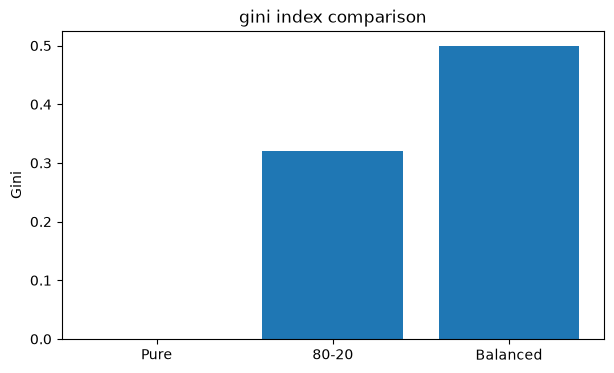

In [5]:
data = ["Pure", "80-20", "Balanced"]
values = [0.0,0.32,0.5]
plt.figure(figsize=(7,4))
plt.bar(data,values)
plt.title("gini index comparison")
plt.ylabel("Gini")
plt.show()


### CART (Classification and Regression Tree)

- It builds a tree by asking simple (yes?no) question
- like : "is feature value < 25000" and keeps splitting until data becomes easier to predict


# Practical

# Basic libraries

In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [51]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split # shuffle + train and split the data
from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score,precision_score, recall_score, f1_score

# Loading dataset

In [52]:
cancer = load_breast_cancer() 

# creating a df and convert dataset into df

In [53]:
df= pd.DataFrame(cancer.data, columns = cancer.feature_names)

In [54]:
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


# add the target col

In [55]:
df['Target'] = cancer.target # Assigns the target variable to the DataFrame

In [56]:
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,Target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


-  It print the shape(size) of df and
 return no of rows and no of col

In [57]:
print("shape :" , df.shape)

shape : (569, 31)


In [58]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         569 non-null

- it count how many times each target value 0 and 1 appear in dataset

In [59]:
print(df['Target'].value_counts()) # Check the distribution of the target variable

Target
1    357
0    212
Name: count, dtype: int64


In [60]:
print(df.isnull().sum())

mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
Target                     0
dtype: int64


## Split IP and OP Data

In [61]:
x= df.drop('Target',axis=1) # 1 col, 0row
y=df['Target']

# train test split

In [62]:
x_train,x_test,y_train,y_test = train_test_split(
    x,y, test_size =0.25,random_state = 42
)

In [63]:
print(x_train.shape)

(426, 30)


In [64]:
print(x_test.shape)

(143, 30)


# Initialize the decision tree model 

In [65]:
model = DecisionTreeClassifier(
    criterion='gini', # or 'entropy'
    random_state =42
)

In [66]:
model

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [67]:
model.fit(x_train,y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

# make predictions

In [68]:
y_pred = model.predict(x_test)

In [69]:
comparison = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred
})

In [70]:
accuracy = accuracy_score(y_test,y_pred)

In [71]:
accuracy

0.951048951048951

In [72]:
precision = precision_score(y_test,y_pred)

In [73]:
precision

0.9659090909090909

In [74]:
confusion_mat = confusion_matrix(y_test,y_pred)
(confusion_mat)

array([[51,  3],
       [ 4, 85]])

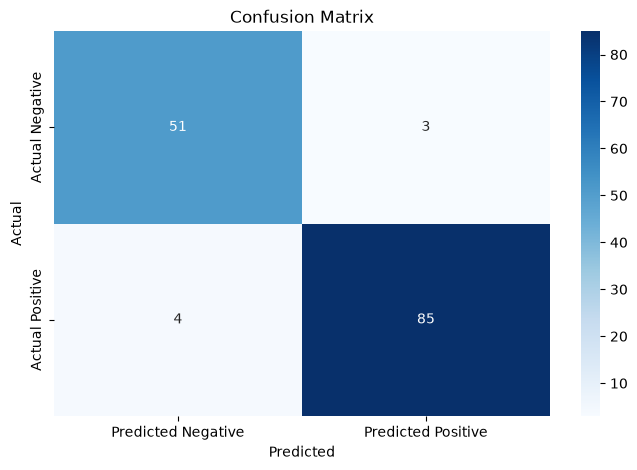

In [75]:
plt.figure(figsize=(8,5))
sns.heatmap(confusion_mat, annot=True, cmap='Blues', xticklabels=['Predicted Negative', 'Predicted Positive'], yticklabels=['Actual Negative', 'Actual Positive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# classification report

In [76]:
print(classification_report(y_test,y_pred)
)

              precision    recall  f1-score   support

           0       0.93      0.94      0.94        54
           1       0.97      0.96      0.96        89

    accuracy                           0.95       143
   macro avg       0.95      0.95      0.95       143
weighted avg       0.95      0.95      0.95       143



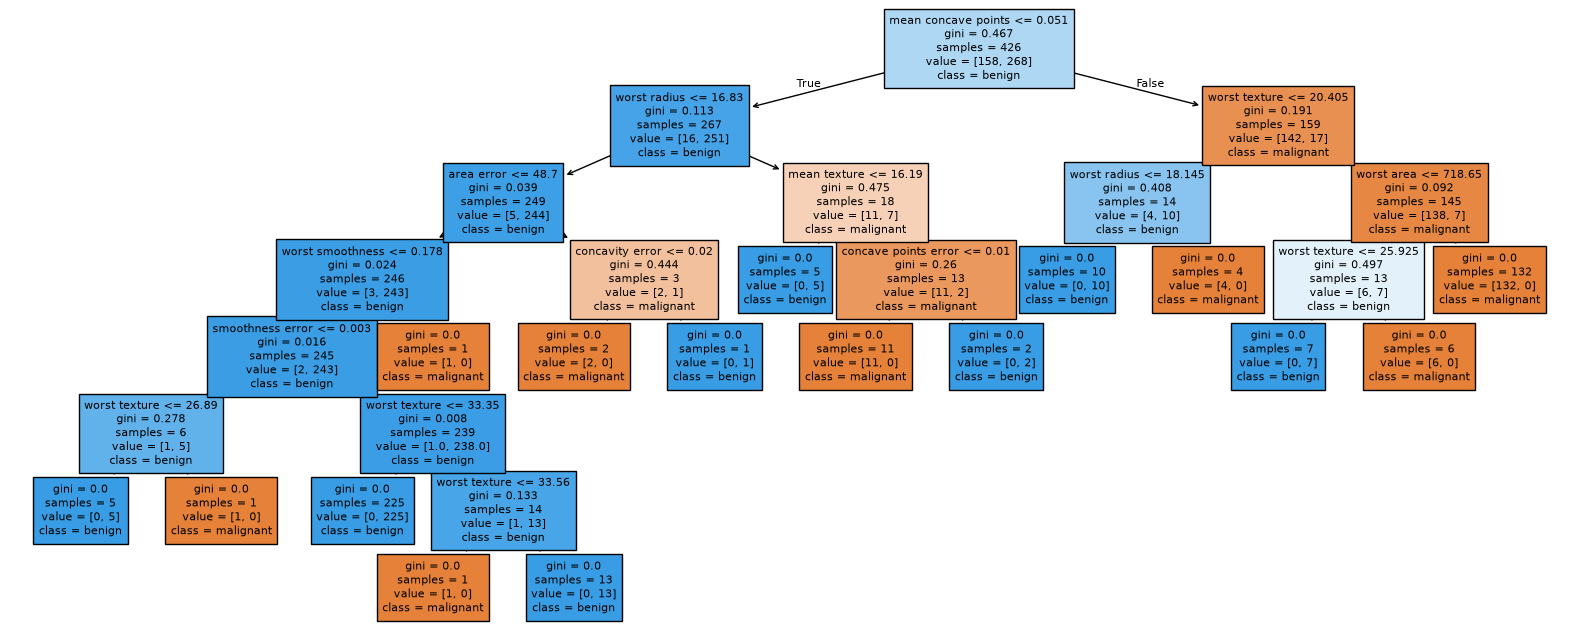

In [78]:
plt.figure(figsize=(20,8))
plot_tree(model, feature_names=cancer.feature_names, class_names=cancer.target_names, filled=True,
          fontsize= 8)
plt.show()